# An Extreme Value Aware Synthetic Financial Data Generator
This script implements a highly sophisticated generative pipeline that bridges
deep latent variable models for discrete structures with Extreme Value Theory (EVT)[cite: 1, 2].

*   **The Problem:** Traditional simple sampling methods exhibit considerable variance when dealing with extreme events, and high-fidelity numerical simulations incur a substantial computational cost[cite: 1]. Furthermore, standard generative adversarial networks struggle to produce robust representations directly when applied to discrete structures[cite: 2].
*   **The Solution:** We deploy an ARAE to map discrete, binned financial market regimes into a continuous latent manifold. This adversarially regularized autoencoder framework allows us to generate natural outputs and perform controlled manipulations in the latent space[cite: 2]. We then train an η-RNG (Random Number Generator) to produce synthetic time-series stress tests. By enforcing extreme event statistics of an observable indicative of extremeness during training, η-learning reduces the uncertainty even in 'uncharted' extreme event regions[cite: 1].
*   **The Bridge:** To prevent dimensional conflicts, a "Translator" network bridges the continuous percentage returns outputted by the RNG with the discrete-trained autoencoder's latent space, preserving flawlessly differentiable gradients for the 1-Wasserstein ($W_1$) penalty[cite: 3].

### Environment Setup

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import norm, genpareto
import matplotlib.pyplot as plt
import os
from google.colab import drive
drive.mount('/content/drive')

# Ensure reproducibility in mathematical operations
torch.manual_seed(42)
np.random.seed(42)

Mounted at /content/drive


### Utility Models: Data Processing & Extreme Value Fitting
This block defines the base mechanisms for fetching raw financial data, discretizing it for the ARAE, and mathematically defining extreme value thresholds. The η-learning methodology relies on a reference distribution that reflects the desired statistical characteristics of the output[cite: 1]. Here, we utilize Generalized Pareto Distributions (GPD) to explicitly model the fat tails (crashes and rallies) of the continuous close returns.

*   `Data_Loader`: Retrieves financial data, calculating standard log returns and localized volume spikes[cite: 3].
*   `Norm_Bin`: Bins continuous returns into strictly bounded categorical integers, enforcing a discrete structure for the autoencoder to eliminate outlier gradients[cite: 3].
*   `Fit_Pareto_Tail`: Utilizes the Peak Over Threshold (POT) method to isolate extreme data points and fit shape, location, and scale parameters[cite: 3].
*   `gpd_icdf`: The inverse cumulative distribution function for the fitted Pareto distribution, used to establish theoretical exceedance boundaries[cite: 3].

In [3]:
class Data_Loader:
    def __init__(self, ticker, start, end):
        self.ohlcv = yf.download(ticker, start=start, end=end).dropna()
        t_ohlcv = pd.DataFrame(index=self.ohlcv.index)
        # Calculate log percentage returns and relative volume
        t_ohlcv['t_o'] = np.log(self.ohlcv['Open']).pct_change()
        t_ohlcv['t_h'] = np.log(self.ohlcv['High']).pct_change()
        t_ohlcv['t_l'] = np.log(self.ohlcv['Low']).pct_change()
        t_ohlcv['t_c'] = np.log(self.ohlcv['Close']).pct_change()
        t_ohlcv['t_v'] = self.ohlcv['Volume']/self.ohlcv['Volume'].rolling(100).mean()
        self.t_ohlcv = t_ohlcv.dropna()

class Norm_Bin:
    def __init__(self, data, size=20):
        mean = torch.mean(data).item()
        std = torch.std(data).item()
        quantiles = torch.linspace(0.01, 0.99, size - 1)
        self.bin_edges = torch.tensor(norm.ppf(quantiles, loc=mean, scale=std), dtype=torch.float32)
        self.binned = self.transform(data)

    def transform(self, new_data):
        word_ids = torch.bucketize(new_data, self.bin_edges)
        return word_ids

class Fit_Pareto_Tail:
    def __init__(self, pct_change, tau=0.05):
        # Directly call the helper method for both tails
        self.shape_l, self.loc_l, self.scale_l, self.threshold_l = self._fit_tail_parameters(pct_change, tau, is_left_tail=True)
        self.shape_r, self.loc_r, self.scale_r, self.threshold_r = self._fit_tail_parameters(pct_change, 1 - tau, is_left_tail=False)

    @staticmethod
    def _fit_tail_parameters(data_series, quantile_for_threshold, is_left_tail):
        if isinstance(data_series, torch.Tensor):
            data_np = data_series.cpu().numpy()
        else:
            data_np = data_series

        threshold = np.quantile(data_np, quantile_for_threshold)

        if is_left_tail:
            extreme_tail = data_np[data_np <= threshold]
            exceedances = -(extreme_tail - threshold)
        else:
            extreme_tail = data_np[data_np >= threshold]
            exceedances = extreme_tail - threshold

        shape, loc, scale = genpareto.fit(exceedances)
        t_shape = torch.tensor(shape, dtype=torch.float32)
        t_loc = torch.tensor(loc, dtype=torch.float32)
        t_scale = torch.tensor(scale, dtype=torch.float32)
        t_threshold = torch.tensor(threshold, dtype=torch.float32)
        return t_shape, t_loc, t_scale, t_threshold

def gpd_icdf(q, loc, scale, shape):
    if shape != 0:
        return loc + (scale / shape) * ((1 - q) ** (-shape) - 1)
    else:
        return loc - scale * torch.log(1 - q)

### Extreme Value Awared Regularization (η-Loss)
The foundational premise of η-learning is that one can incorporate a priori available statistical information into the training process[cite: 1]. The `generative_eta_loss` accomplishes this by calculating the Mean Squared Error (MSE) to anchor the sequence near realistic volatility, while applying a severe 1-Wasserstein ($W_1$) penalty to the tails[cite: 3].

*   The $W_1$ distance is mathematically calculated between the sorted generated tails and the theoretical GPD exceedances[cite: 3].
*   The `lambda_param` weights the Wasserstein-1 distance of the tails, dictating the severity of the statistical regularization[cite: 3].
*   This approach seamlessly integrates the predictive fidelity of supervised learning in well-sampled regions with an awareness of high-impact scenarios in data-scarce regions[cite: 1].

In [4]:
def generative_eta_loss(synthetic_returns, naive_inputs, lambda_param, pareto_params):
    mse = torch.nn.functional.mse_loss(synthetic_returns, naive_inputs)
    device = synthetic_returns.device

    # Unpack the globally fitted tail parameters
    shape_l, loc_l, scale_l, thresh_l = [p.to(device) for p in (pareto_params.shape_l, pareto_params.loc_l, pareto_params.scale_l, pareto_params.threshold_l)]
    shape_r, loc_r, scale_r, thresh_r = [p.to(device) for p in (pareto_params.shape_r, pareto_params.loc_r, pareto_params.scale_r, pareto_params.threshold_r)]

    # Isolate Tails using the GLOBAL thresholds
    tail_preds_left = synthetic_returns[synthetic_returns <= thresh_l]
    tail_preds_right = synthetic_returns[synthetic_returns >= thresh_r]

    W1_left = torch.tensor(0.0, device=device)
    W1_right = torch.tensor(0.0, device=device)

    # Process Left Tail (Crashes)
    if len(tail_preds_left) >= 2:
        tail_preds_l_sorted, _ = torch.sort(tail_preds_left.squeeze())
        K_l = len(tail_preds_l_sorted)
        q_grid_l = torch.linspace(K_l / (K_l + 1), 1 / (K_l + 1), K_l, device=device)
        theoretical_exceedances_l = gpd_icdf(q_grid_l, loc_l, scale_l, shape_l)
        tail_true_theoretical_l = thresh_l - theoretical_exceedances_l
        W1_left = torch.mean(torch.abs(tail_preds_l_sorted - tail_true_theoretical_l))

    # Process Right Tail (Rallies)
    if len(tail_preds_right) >= 2:
        tail_preds_r_sorted, _ = torch.sort(tail_preds_right.squeeze())
        K_r = len(tail_preds_r_sorted)
        q_grid_r = torch.linspace(1 / (K_r + 1), K_r / (K_r + 1), K_r, device=device)
        theoretical_exceedances_r = gpd_icdf(q_grid_r, loc_r, scale_r, shape_r)
        tail_true_theoretical_r = thresh_r + theoretical_exceedances_r
        W1_right = torch.mean(torch.abs(tail_preds_r_sorted - tail_true_theoretical_r))

    # Unified Lambda Weighting
    W1_total = W1_left + W1_right
    total_loss = mse + (lambda_param * W1_total)

    return total_loss, mse, W1_total

### Data Preparation & Rolling Windows
To construct sequences that appropriately convey temporal dynamics to the Recurrent Neural Networks (RNNs), data must be framed sequentially. We establish a custom rolling window function that generates overlapping 21-day segments.
*   We extract both the continuous `Close` sequences (for the Translator and η-loss) and the fully binned 5-feature sequences (for the Discrete Autoencoder).
*   The global Pareto parameters are established strictly on the empirical, continuous percentage returns, ensuring the mathematical purity of the extreme value fit[cite: 3].

In [5]:
# 1. Fetch data
GSPC = Data_Loader('^GSPC', '2000-01-01', '2023-12-31')
close_returns_tensor = torch.tensor(GSPC.t_ohlcv['t_c'].values, dtype=torch.float32)

# 2. Fit the Pareto tails globally on the raw historical Close percentage returns
global_pareto_params = Fit_Pareto_Tail(close_returns_tensor, tau=0.05)

# 3. Discretize Features
t_o = torch.tensor(GSPC.t_ohlcv['t_o'].values, dtype=torch.float32)
t_h = torch.tensor(GSPC.t_ohlcv['t_h'].values, dtype=torch.float32)
t_l = torch.tensor(GSPC.t_ohlcv['t_l'].values, dtype=torch.float32)
t_c = torch.tensor(GSPC.t_ohlcv['t_c'].values, dtype=torch.float32)
t_v = torch.tensor(GSPC.t_ohlcv['t_v'].values, dtype=torch.float32)

o = Norm_Bin(t_o, 20)
h = Norm_Bin(t_h, 20)
l = Norm_Bin(t_l, 20)
c = Norm_Bin(t_c, 20)
v = Norm_Bin(t_v, 5)

GSPC_binned = torch.cat((o.binned.unsqueeze(1), h.binned.unsqueeze(1),
                         l.binned.unsqueeze(1), c.binned.unsqueeze(1),
                         v.binned.unsqueeze(1)), dim=1)

# 4. Generate Rolling Windows
def create_rolling_windows(continuous_data, binned_data, window_size=21):
    cont_windows, bin_windows = [], []
    for i in range(len(continuous_data) - window_size + 1):
        cont_windows.append(continuous_data[i:i+window_size])
        bin_windows.append(binned_data[i:i+window_size])
    return torch.stack(cont_windows), torch.stack(bin_windows)

cont_windows, bin_windows = create_rolling_windows(close_returns_tensor, GSPC_binned, window_size=21)

# Ensure dimensions are (batch, seq, feature)
cont_windows = cont_windows.unsqueeze(-1)

Dictionary = DataLoader(TensorDataset(bin_windows, cont_windows), batch_size=32, drop_last=True, shuffle=True, num_workers=2)

/tmp/ipykernel_1621/1462353129.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.ohlcv = yf.download(ticker, start=start, end=end).dropna()
[*********************100%***********************]  1 of 1 completed


### ARAE Autoencoder Architectures (Market Manifold)
The Adversarially Regularized Autoencoder consists of an encoder mapping an input space to a continuous latent space and a conditional decoder operating over the discrete structures[cite: 2].
*   **`PatternEncoder`**: Utilizes `nn.Embedding` layers to project discrete integers into a densely populated, continuous representational vector, rectifying the gradient distortion created by feeding categorical IDs into linear transformations.
*   **`PatternDecoder`**: Receives the abstract latent space and distributes it via `nn.Linear` layers into 85 unnormalized probability distributions (logits). This configuration allows cross-entropy to accurately penalize the reconstruction of the categorized market data.

In [6]:
class PatternEncoder(nn.Module):
    def __init__(self, window=21, embed_dim=20):
        super().__init__()
        self.emb_ohlc = nn.Embedding(20, embed_dim)
        self.emb_v = nn.Embedding(5, embed_dim)
        self.feature_blender = nn.Linear(in_features=embed_dim * 5, out_features=1)

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=window,
            num_layers=2,
            dropout=0.05,
            batch_first=True
        )

    def forward(self, x):
        o_emb = self.emb_ohlc(x[:, :, 0])
        h_emb = self.emb_ohlc(x[:, :, 1])
        l_emb = self.emb_ohlc(x[:, :, 2])
        c_emb = self.emb_ohlc(x[:, :, 3])
        v_emb = self.emb_v(x[:, :, 4])

        concatenated = torch.cat([o_emb, h_emb, l_emb, c_emb, v_emb], dim=-1)
        blended_x = self.feature_blender(concatenated)

        _, h_n = self.gru(blended_x)
        # h_n shape for 2 layers is (2, batch, window). We take the final layer's hidden state:
        return h_n[-1]

class PatternDecoder(nn.Module):
    def __init__(self, window=21):
        super().__init__()
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=window,
            num_layers=2,
            dropout=0.05,
            batch_first=True
        )

        self.feature_unblender = nn.Linear(in_features=window, out_features=5)

        self.out_o = nn.Linear(1, 20)
        self.out_h = nn.Linear(1, 20)
        self.out_l = nn.Linear(1, 20)
        self.out_c = nn.Linear(1, 20)
        self.out_v = nn.Linear(1, 5)

    def forward(self, h):
        h_seq = h.unsqueeze(-1)
        gru_out, _ = self.gru(h_seq)

        unblended_y = self.feature_unblender(gru_out)

        logits_o = self.out_o(unblended_y[:, :, 0:1])
        logits_h = self.out_h(unblended_y[:, :, 1:2])
        logits_l = self.out_l(unblended_y[:, :, 2:3])
        logits_c = self.out_c(unblended_y[:, :, 3:4])
        logits_v = self.out_v(unblended_y[:, :, 4:5])

        return logits_o, logits_h, logits_l, logits_c, logits_v

### Translator, RNG, Generator, & Critic Architectures (Stress Framework)
This block establishes the bridge between the continuous extreme value distributions and the discrete ARAE framework. By formalizing the adversarial autoencoder as an optimal transport problem, the underlying generator mapping is tightly regulated[cite: 2].

*   **`RNG` (The Shock Engine)**: Expands baseline statistical noise across a `(batch, 21, 1)` continuum. Rather than outputting latent space mappings directly, it outputs *continuous percentage returns* formatted to fat-tailed extremes.
*   **`Translator`**: A recurrent network bridging those sequences of continuous Close returns to the exact mathematical geometry of the 21-dimensional Latent Vector.
*   **`Generator` (The ARAE Prior)**: A learned parameterized network that takes the translated signal and adversarially refines it into the final latent space representation[cite: 2].
*   **`Critic`**: A dense perceptron optimized to delineate between actual market state vectors (from the Encoder) and synthesized vectors (from the Generator)[cite: 2].

In [7]:
class Translator(nn.Module):
    def __init__(self, window=21):
        super().__init__()
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=window,
            num_layers=1,
            batch_first=True
        )

    def forward(self, x):
        _, h_n = self.gru(x)
        return h_n.squeeze(0)

class RNG(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x shape (batch, seq, 1) - applies linearly per sequence step
        return self.network(x)

class Critic(nn.Module):
    def __init__(self, hidden_dim=21):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, z):
        return self.net(z)

class Generator(nn.Module):
    def __init__(self, hidden_dim=21):
        super().__init__()
        # Standard MLP Generator mapping the translated noise to the final latent space
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, hidden_dim)
        )

    def forward(self, x):
        return self.net(x)

### Model Initialization
Here we deploy instances of the defined network architectures and attach highly specialized optimizers to orchestrate the partitioned training logic.

In [8]:
# 1. ADD THIS AT THE TOP OF YOUR MODEL INITIALIZATION
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

encoder = PatternEncoder().to(device)
decoder = PatternDecoder().to(device)
translator = Translator().to(device)
rng = RNG().to(device)
critic = Critic().to(device)
generator = Generator().to(device)

# Optimizers isolated for phase-specific training
opt_ae = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)
opt_translator = torch.optim.Adam(translator.parameters(), lr=1e-3)
opt_rng = torch.optim.Adam(rng.parameters(), lr=1e-3)
opt_critic = torch.optim.Adam(critic.parameters(), lr=5e-5)
opt_generator = torch.optim.Adam(generator.parameters(), lr=5e-5)

Using device: cuda


### Phase 1: Training the ARAE (Market Memory)
This sequence maps historical market topologies, utilizing Cross Entropy to penalize discrepancies in discrete reconstruction. The cross-entropy loss acts upon the network outputs precisely as it would bound the total variational distance between discrete distributions[cite: 2]. The loss calculates the independent accuracy of the Open, High, Low, Close, and Volume predictions, summing them to ensure total sequence cohesion.

In [9]:
print("--- Starting Phase 1: Autoencoder Training ---")
encoder.train()
decoder.train()
ae_epochs = 11 #1500
for epoch in range(ae_epochs):
    epoch_loss = 0
    for batch_bins, _ in Dictionary:
        batch_bins = batch_bins.to(device)
        opt_ae.zero_grad()

        z_real = encoder(batch_bins)
        log_o, log_h, log_l, log_c, log_v = decoder(z_real)

        # Flatten for CrossEntropyLoss which expects (Batch*Seq, Classes)
        # Targets are expected to be (Batch*Seq)
        b_flat = batch_bins.view(-1, 5)

        loss_o = F.cross_entropy(log_o.view(-1, 20), b_flat[:, 0])
        loss_h = F.cross_entropy(log_h.view(-1, 20), b_flat[:, 1])
        loss_l = F.cross_entropy(log_l.view(-1, 20), b_flat[:, 2])
        loss_c = F.cross_entropy(log_c.view(-1, 20), b_flat[:, 3])
        loss_v = F.cross_entropy(log_v.view(-1, 5), b_flat[:, 4])

        total_ae_loss = loss_o + loss_h + loss_l + loss_c + loss_v
        total_ae_loss.backward()
        opt_ae.step()

        epoch_loss += total_ae_loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"AE Epoch {epoch+1:04d} | Total Loss: {epoch_loss/len(Dictionary):.6f}")

--- Starting Phase 1: Autoencoder Training ---
AE Epoch 0010 | Total Loss: 11.756296


### Checkpoint 1

#### Save Model

In [10]:
# Define your custom Drive folder path
save_dir = '/content/drive/MyDrive/STSG_Models'
os.makedirs(save_dir, exist_ok=True) # Creates the folder if it doesn't exist

# Package and save only the Encoder and Decoder weights
arae_checkpoint = {
    'encoder': encoder.state_dict(),
    'decoder': decoder.state_dict()
}

file_path = os.path.join(save_dir, 'arae_models.pth')
torch.save(arae_checkpoint, file_path)
print(f"--- ARAE models successfully saved to Google Drive: {file_path} ---")

--- ARAE models successfully saved to Google Drive: /content/drive/MyDrive/STSG_Models/arae_models.pth ---


#### Load Model

In [11]:
# Path to your saved weights in Google Drive
save_dir = '/content/drive/MyDrive/STSG_Models'
file_path = os.path.join(save_dir, 'arae_models.pth')

# Load the checkpoint
arae_checkpoint = torch.load(file_path, map_location=device)

# Restore weights into the encoder and decoder
encoder.load_state_dict(arae_checkpoint['encoder'])
decoder.load_state_dict(arae_checkpoint['decoder'])

encoder.eval()
decoder.eval()

print("--- Pre-trained ARAE models successfully loaded from Google Drive! ---")

--- Pre-trained ARAE models successfully loaded from Google Drive! ---


###### Continue Training

In [12]:
encoder.train()
decoder.train()
opt_ae = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)

### Phase 2: Training the Translator (The Bridge)
With the Autoencoder firmly establishing the structure of the latent market space, it is subsequently frozen. The Translator receives the continuous real-world Close sequences and is trained via Mean Squared Error to successfully predict the corresponding 21D Latent Vector generated by the Encoder. This explicitly links continuous physical extremes directly to discrete structural generation limits.

In [13]:
print("\n--- Starting Phase 2: Translator Training ---")
encoder.eval()
trans_epochs = 11 # 600

for epoch in range(trans_epochs):
    epoch_loss = 0
    for batch_bins, batch_cont in Dictionary:
        batch_bins = batch_bins.to(device)
        batch_cont = batch_cont.to(device)
        opt_translator.zero_grad()

        with torch.no_grad():
            z_real = encoder(batch_bins)

        z_pred = translator(batch_cont)
        loss_trans = F.mse_loss(z_pred, z_real)
        loss_trans.backward()
        opt_translator.step()
        epoch_loss += loss_trans.item()

    if (epoch + 1) % 10 == 0:
        print(f"Translator Epoch {epoch+1:04d} | MSE Loss: {epoch_loss/len(Dictionary):.6f}")


--- Starting Phase 2: Translator Training ---
Translator Epoch 0010 | MSE Loss: 0.078701


### Checkpoint 2

#### Save Model

In [14]:
# Define your custom Drive folder path
save_dir = '/content/drive/MyDrive/STSG_Models'
os.makedirs(save_dir, exist_ok=True) # Creates the folder if it doesn't exist

# Package and save only the Encoder and Decoder weights
araet_checkpoint = {
    'encoder': encoder.state_dict(),
    'decoder': decoder.state_dict(),
    'translator' : translator.state_dict()

}

file_path = os.path.join(save_dir, 'araet_models.pth')
torch.save(araet_checkpoint, file_path)
print(f"--- ARAE models successfully saved to Google Drive: {file_path} ---")

--- ARAE models successfully saved to Google Drive: /content/drive/MyDrive/STSG_Models/araet_models.pth ---


#### Load Model

In [15]:
# Path to your saved weights in Google Drive
save_dir = '/content/drive/MyDrive/STSG_Models'
file_path = os.path.join(save_dir, 'araet_models.pth')

# Load the checkpoint
arae_checkpoint = torch.load(file_path, map_location=device)

# Restore weights into the encoder and decoder
encoder.load_state_dict(arae_checkpoint['encoder'])
decoder.load_state_dict(arae_checkpoint['decoder'])
translator.load_state_dict(arae_checkpoint['translator'])

encoder.eval()
decoder.eval()
translator.eval()

print("--- Pre-trained ARAET models successfully loaded from Google Drive! ---")

--- Pre-trained ARAET models successfully loaded from Google Drive! ---


### Phase 3: Independent Fat-Tail RNG Training
In this phase, we isolate the RNG to explicitly learn the mathematical bounds of extreme market events before introducing adversarial dynamics. The foundational premise of η-learning is that one can incorporate a priori available statistical information into the training process[cite: 1].

*   The `RNG` is injected with continuous naive noise, deriving its mean and variance purely from empirical historical data.
*   Instead of adversarial feedback, the RNG's continuous sequence forecasts are actively and exclusively regularized by the $\eta$-loss[cite: 1].
*   This objective balances a Mean Squared Error (MSE) to anchor realistic volatility with a severe 1-Wasserstein ($W_1$) penalty, forcing the synthetic tail probabilities to align tightly with the analytical Generalized Pareto Distribution (GPD) bounds[cite: 1].
*   By isolating this step, we ensure the shock layer produces physically meaningful extremes without the instability of GAN training.

In [16]:
print("\n--- Starting Phase 3: Independent Fat-Tail RNG Training ---")

# Freeze all other networks to ensure ONLY the RNG learns here
translator.eval()
encoder.eval()
decoder.eval()

# Retrieve statistical constants for naive noise injection
hist_mean = torch.mean(close_returns_tensor).item()
hist_std = torch.std(close_returns_tensor).item()

opt_rng = torch.optim.Adam(rng.parameters(), lr=1e-3)
rng_pre_epochs = 1000  # Restored to your original 1000 loop requirement

for epoch in range(rng_pre_epochs):
    rng.train()
    epoch_loss = 0
    epoch_mse = 0
    epoch_w1 = 0

    # Lambda Scheduling: Delay the W1 tail penalty to prevent the Identity Trap
    current_lambda = 0.0 if epoch < 300 else 1.0

    for _ in range(len(Dictionary)):
        opt_rng.zero_grad()

        # 1. Generate naive noise batch
        naive_inputs = torch.normal(mean=hist_mean, std=hist_std, size=(32, 21, 1)).to(device)

        # 2. RNG creates continuous synthetic returns
        synthetic_returns = rng(naive_inputs)

        # 3. Apply Eta-Loss (MSE + W1 tail regularization against global Pareto parameters)
        total_loss, mse, w1_dist = generative_eta_loss(
            synthetic_returns, naive_inputs, lambda_param=current_lambda, pareto_params=global_pareto_params
        )

        total_loss.backward()
        opt_rng.step()

        epoch_loss += total_loss.item()
        epoch_mse += mse.item()
        epoch_w1 += w1_dist.item() if isinstance(w1_dist, torch.Tensor) else w1_dist

    if (epoch + 1) % 50 == 0:
        print(f"RNG Pre-train Epoch {epoch+1:04d} | Lambda: {current_lambda} | MSE: {epoch_mse/len(Dictionary):.6f} | W1 Tail: {epoch_w1/len(Dictionary):.6f}")

print("--- Phase 3 Complete: RNG Fat-Tail Training Finished ---")


--- Starting Phase 3: Independent Fat-Tail RNG Training ---
RNG Pre-train Epoch 0050 | Lambda: 0.0 | MSE: 0.000000 | W1 Tail: 0.001735
RNG Pre-train Epoch 0100 | Lambda: 0.0 | MSE: 0.000000 | W1 Tail: 0.001764
RNG Pre-train Epoch 0150 | Lambda: 0.0 | MSE: 0.000000 | W1 Tail: 0.001799
RNG Pre-train Epoch 0200 | Lambda: 0.0 | MSE: 0.000000 | W1 Tail: 0.001784
RNG Pre-train Epoch 0250 | Lambda: 0.0 | MSE: 0.000000 | W1 Tail: 0.001768
RNG Pre-train Epoch 0300 | Lambda: 0.0 | MSE: 0.000000 | W1 Tail: 0.001769
RNG Pre-train Epoch 0350 | Lambda: 1.0 | MSE: 0.000001 | W1 Tail: 0.001252
RNG Pre-train Epoch 0400 | Lambda: 1.0 | MSE: 0.000001 | W1 Tail: 0.001202
RNG Pre-train Epoch 0450 | Lambda: 1.0 | MSE: 0.000002 | W1 Tail: 0.001190
RNG Pre-train Epoch 0500 | Lambda: 1.0 | MSE: 0.000002 | W1 Tail: 0.001191
RNG Pre-train Epoch 0550 | Lambda: 1.0 | MSE: 0.000001 | W1 Tail: 0.001151
RNG Pre-train Epoch 0600 | Lambda: 1.0 | MSE: 0.000001 | W1 Tail: 0.001184
RNG Pre-train Epoch 0650 | Lambda: 1.0 

### Checkpoint 3

#### Save Model

In [17]:
# Define your custom Drive folder path
save_dir = '/content/drive/MyDrive/STSG_Models'
os.makedirs(save_dir, exist_ok=True)

# Package Phase 1, 2, and 3 weights together
phase3_checkpoint = {
    'encoder': encoder.state_dict(),
    'decoder': decoder.state_dict(),
    'translator' : translator.state_dict(),
    'rng' : rng.state_dict()
}

file_path = os.path.join(save_dir, 'araetr_models.pth')
torch.save(phase3_checkpoint, file_path)
print(f"--- Phase 3 models (ARAE + Translator + RNG) successfully saved to {file_path} ---")

--- Phase 3 models (ARAE + Translator + RNG) successfully saved to /content/drive/MyDrive/STSG_Models/araetr_models.pth ---


#### Load Model

In [18]:
save_dir = '/content/drive/MyDrive/STSG_Models'
file_path = os.path.join(save_dir, 'araetr_models.pth')
phase3_checkpoint = torch.load(file_path, map_location=device)

encoder.load_state_dict(phase3_checkpoint['encoder'])
decoder.load_state_dict(phase3_checkpoint['decoder'])
translator.load_state_dict(phase3_checkpoint['translator'])
rng.load_state_dict(phase3_checkpoint['rng'])

# Set everything to eval before moving to the next steps
encoder.eval()
decoder.eval()
translator.eval()
rng.eval()

print("--- Pre-trained Phase 3 models successfully loaded from Google Drive! ---")

--- Pre-trained Phase 3 models successfully loaded from Google Drive! ---


### Phase 4: Adversarial Generator & Critic Training
The final phase operationalizes the Wasserstein Autoencoder (WAE) optimal transport objective to ensure the generated extremes respect the structural realities of the market[cite: 2]. With the `RNG` trained to produce fat-tailed continuous paths and the `Translator` trained to bridge continuous sequences into the latent space, both are now frozen.

*   The continuous stress sequence passes through the `Translator` to form an initial, bridged latent signal.
*   The `Generator` (acting as the learned parameterized prior) receives this translated signal and adversarially refines it into the final synthetic latent vector, $z_{fake}$[cite: 2].
*   The `Critic` acts as a discriminator, attempting to delineate between actual market state vectors mapped by the `Encoder` ($z_{real}$) and the synthesized vectors mapped by the `Generator` ($z_{fake}$)[cite: 2].
*   The `Generator` adjusts its weights exclusively to fool the Critic, seamlessly integrating the extreme value shocks into the natural, continuous manifold of the autoencoder[cite: 2].

In [19]:
print("\n--- Starting Phase 4: Adversarial Generator & Critic Training ---")

# The RNG and Translator have learned their mappings, so we evaluate/freeze them.
# We ONLY train the Generator and Critic here.
rng.eval()
translator.eval()
encoder.eval()

generator.train()
critic.train()

opt_critic = torch.optim.Adam(critic.parameters(), lr=1e-4)
opt_generator = torch.optim.Adam(generator.parameters(), lr=1e-3)

gan_epochs = 1000
clip_value = 0.01

for epoch in range(gan_epochs):
    critic_epoch_loss = 0
    gen_epoch_loss = 0

    for batch_idx, (batch_bins, _) in enumerate(Dictionary):
        batch_bins = batch_bins.to(device)
        batch_size = batch_bins.size(0)

        # ==========================================
        # 1. Train Critic
        # ==========================================
        opt_critic.zero_grad()

        with torch.no_grad():
            z_real = encoder(batch_bins)
            naive_inputs = torch.normal(mean=hist_mean, std=hist_std, size=(batch_size, 21, 1)).to(device)
            synthetic_cont = rng(naive_inputs)
            s_prime = translator(synthetic_cont)

        # The Generator takes the translated signal (s') and creates the fake latent (z_fake)
        z_fake = generator(s_prime)

        real_preds = critic(z_real)
        fake_preds = critic(z_fake.detach()) # Detach so gradients don't flow back to Generator yet

        loss_critic = -(torch.mean(real_preds) - torch.mean(fake_preds))
        loss_critic.backward()
        opt_critic.step()

        # Enforce 1-Lipschitz constraint via weight clipping (from ARAE paper)
        for p in critic.parameters():
            p.data.clamp_(-clip_value, clip_value)

        critic_epoch_loss += loss_critic.item()

        # ==========================================
        # 2. Train Generator
        # ==========================================
        if batch_idx % 5 == 0:
            opt_generator.zero_grad()

            # Recalculate fake_preds with gradients attached
            gen_preds = critic(z_fake)

            # WGAN Generator Loss: Trick the critic into scoring it as real (negative loss)
            loss_generator = -torch.mean(gen_preds)
            loss_generator.backward()
            opt_generator.step()

            gen_epoch_loss += loss_generator.item()

    if (epoch + 1) % 50 == 0:
        print(f"GAN Epoch {epoch+1:04d} | Critic Loss: {critic_epoch_loss/len(Dictionary):.4f} | Generator Loss: {gen_epoch_loss/len(Dictionary):.4f}")

print("--- Phase 4 Complete: Adversarial Training Finished ---")


--- Starting Phase 4: Adversarial Generator & Critic Training ---
GAN Epoch 0050 | Critic Loss: -0.0103 | Generator Loss: -0.0022
GAN Epoch 0100 | Critic Loss: 0.0008 | Generator Loss: 0.0007
GAN Epoch 0150 | Critic Loss: -0.0110 | Generator Loss: 0.0014
GAN Epoch 0200 | Critic Loss: -0.0066 | Generator Loss: 0.0012
GAN Epoch 0250 | Critic Loss: -0.0046 | Generator Loss: 0.0019
GAN Epoch 0300 | Critic Loss: -0.0065 | Generator Loss: 0.0026
GAN Epoch 0350 | Critic Loss: -0.0073 | Generator Loss: 0.0020
GAN Epoch 0400 | Critic Loss: -0.0133 | Generator Loss: -0.0020
GAN Epoch 0450 | Critic Loss: -0.0068 | Generator Loss: -0.0020
GAN Epoch 0500 | Critic Loss: -0.0092 | Generator Loss: -0.0019
GAN Epoch 0550 | Critic Loss: -0.0050 | Generator Loss: -0.0020
GAN Epoch 0600 | Critic Loss: -0.0040 | Generator Loss: 0.0010
GAN Epoch 0650 | Critic Loss: -0.0071 | Generator Loss: 0.0015
GAN Epoch 0700 | Critic Loss: -0.0083 | Generator Loss: 0.0017
GAN Epoch 0750 | Critic Loss: -0.0064 | Generat

### Checkpoint 4

#### Save Model

In [20]:
# Define your custom Drive folder path
save_dir = '/content/drive/MyDrive/STSG_Models'
os.makedirs(save_dir, exist_ok=True)

# Package the FULL pipeline weights securely
final_checkpoint = {
    'encoder': encoder.state_dict(),
    'decoder': decoder.state_dict(),
    'translator' : translator.state_dict(),
    'rng' : rng.state_dict(),
    'generator' : generator.state_dict(),
    'critic' : critic.state_dict()
}

file_path = os.path.join(save_dir, 'STSG_full_models.pth')
torch.save(final_checkpoint, file_path)
print(f"--- Full Generator Pipeline successfully saved to {file_path} ---")

--- Full Generator Pipeline successfully saved to /content/drive/MyDrive/STSG_Models/STSG_full_models.pth ---


#### Load Model

In [21]:
save_dir = '/content/drive/MyDrive/STSG_Models'
file_path = os.path.join(save_dir, 'STSG_full_models.pth')
final_checkpoint = torch.load(file_path, map_location=device)

# Restore weights for the entire architecture
encoder.load_state_dict(final_checkpoint['encoder'])
decoder.load_state_dict(final_checkpoint['decoder'])
translator.load_state_dict(final_checkpoint['translator'])
rng.load_state_dict(final_checkpoint['rng'])
generator.load_state_dict(final_checkpoint['generator'])
critic.load_state_dict(final_checkpoint['critic'])

# Set all models to eval mode ready for final generation
encoder.eval()
decoder.eval()
translator.eval()
rng.eval()
generator.eval()
critic.eval()

print("--- Full Pre-trained Pipeline successfully loaded and ready for generation! ---")

--- Full Pre-trained Pipeline successfully loaded and ready for generation! ---


### Final Execution: Synthetic Black Swan Generation & Visualization
With training concluded, the pipeline generates physically meaningful extremes consistent with the reference laws[cite: 1]. The `RNG` generates mathematically precise continuous tail events. The `Translator` bridges them to the latent manifold, and the `PatternDecoder` accurately projects the correlating sequence states across Open, High, Low, Close, and Volume. We then plot the continuous Close returns as a price path starting from a base price of 1000.

Generated Extreme Close Return (Bins) Shape: torch.Size([5, 21])
Sample Synthetic Path Bins:
 tensor([ 9, 10,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10,  9,  9,  9,  9,  9,  9,
         9,  9,  9], device='cuda:0')


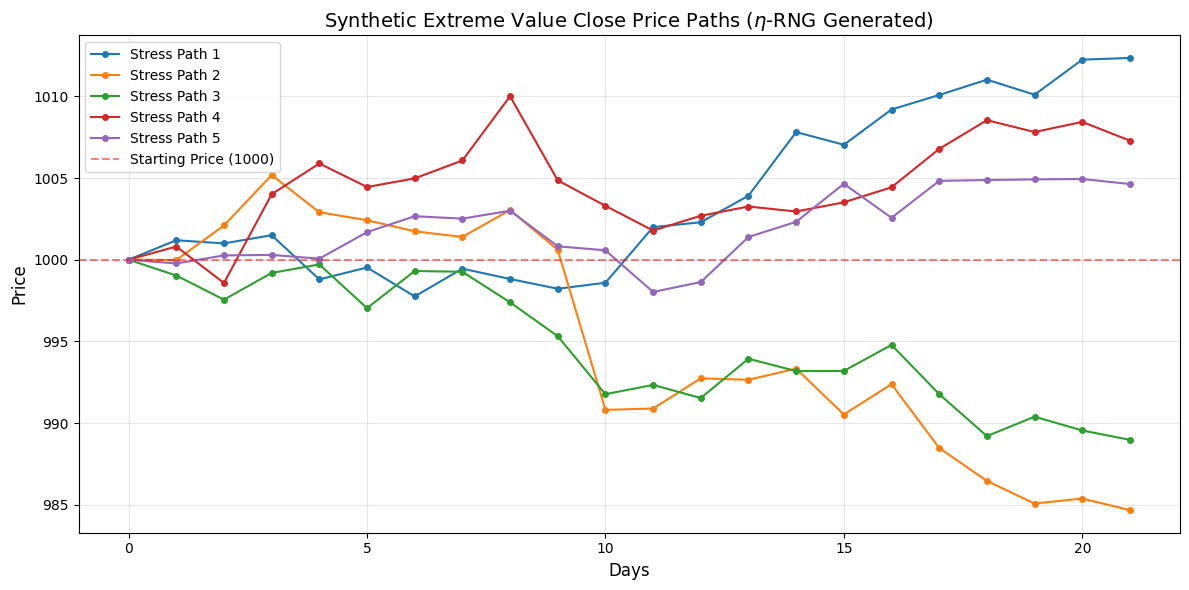

In [22]:
rng.eval()
translator.eval()
generator.eval()
decoder.eval()

num_paths = 5
base_price = 1000.0

with torch.no_grad():
    # 1. Start with statistical noise
    naive_inputs = torch.normal(mean=hist_mean, std=hist_std, size=(num_paths, 21, 1)).to(device)

    # 2. Forge the extreme continuous close sequence (RNG Layer)
    synthetic_cont_close = rng(naive_inputs)

    # 3. Translate continuous extremes into the intermediate space (Bridge Layer)
    s_prime = translator(synthetic_cont_close)

    # 4. Refine into the final Autoencoder latent manifold (Generator Layer)
    z_synthetic = generator(s_prime)

    # 5. Decode the latent space into fully synchronized market variables
    log_o, log_h, log_l, log_c, log_v = decoder(z_synthetic)

    # Extract specific discrete predictions via Argmax for the overall market state
    synth_close_bins = torch.argmax(log_c, dim=-1)

# Extract the continuous returns for plotting
# Shape goes from (num_paths, 21, 1) -> (num_paths, 21)
continuous_returns = synthetic_cont_close.squeeze(-1).cpu().numpy()

# Calculate cumulative price paths
# We create an array of 22 steps to include the Day 0 base price
price_paths = np.zeros((num_paths, 22))
price_paths[:, 0] = base_price

for i in range(1, 22):
    price_paths[:, i] = price_paths[:, i-1] * (1 + continuous_returns[:, i-1])

print(f"Generated Extreme Close Return (Bins) Shape: {synth_close_bins.shape}")
print(f"Sample Synthetic Path Bins:\n {synth_close_bins[0]}")

# Plotting the Black Swan Scenarios
plt.figure(figsize=(12, 6))
for i in range(num_paths):
    plt.plot(price_paths[i], marker='o', markersize=4, label=f'Stress Path {i+1}')

plt.title('Synthetic Extreme Value Close Price Paths ($\\eta$-RNG Generated)', fontsize=14)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.axhline(y=base_price, color='r', linestyle='--', alpha=0.5, label='Starting Price (1000)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()